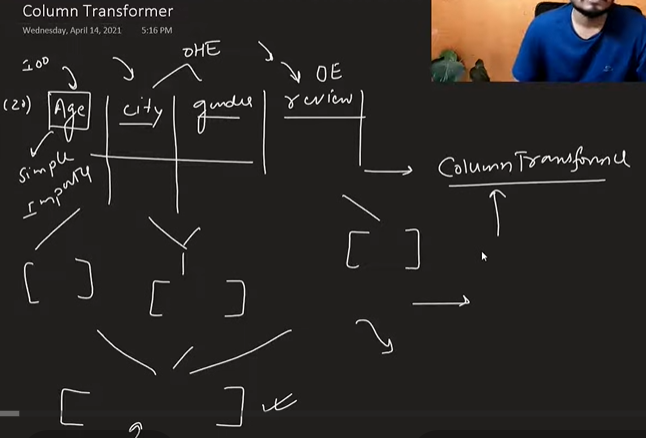

As for final array we need to combine 3 arrays with 3 diff processes, it is not efficient

column transform is used, which reduces this process to a single line of code

In [1]:
import pandas as pd
import numpy as np

In [6]:
df=pd.read_csv('covid_toy.csv')
df.sample(5)

,age,gender,fever,cough,city,has_covid
32,34,Female,101.0,Strong,Delhi,Yes
60,24,Female,102.0,Strong,Bangalore,Yes
37,55,Male,100.0,Mild,Kolkata,No
93,27,Male,100.0,Mild,Kolkata,Yes
86,25,Male,104.0,Mild,Bangalore,Yes


In [3]:
# age,fever are numerical(manual imputation)
# cough is ordinal(OE)
# rest are nominal(OHE)
# label encoding for o/p

In [27]:
# train test split for ordinal encoding(cough)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df[['cough']],df.iloc[:,-1],test_size=0.2, random_state=42)

In [28]:
x_train

,cough
55,Mild
88,Mild
26,Mild
42,Mild
69,Mild
...,...
60,Strong
71,Strong
14,Mild
92,Strong


In [29]:
df[['cough']].value_counts()

cough 
Mild      62
Strong    38
Name: count, dtype: int64

In [30]:
from sklearn.preprocessing import OrdinalEncoder

In [31]:
oe=OrdinalEncoder(categories=[['Mild','Strong']])

In [32]:
x_train_new=oe.fit_transform(x_train)
x_test_new=oe.transform(x_test)

In [56]:
x_train_new.shape

(80, 1)

In [35]:
#OHE for gender,city

In [44]:
# train test split for ohe
from sklearn.model_selection import train_test_split
x1_train,x1_test,y1_train,y1_test=train_test_split(df[['gender','city']],df.iloc[:,-1],test_size=0.2, random_state=42)

In [45]:
pd.get_dummies(df[['gender','city']],drop_first=True,dtype=np.int32)

,gender_Male,city_Delhi,city_Kolkata,city_Mumbai
0,1,0,1,0
1,1,1,0,0
2,1,1,0,0
3,0,0,1,0
4,0,0,0,1
...,...,...,...,...
95,0,0,0,0
96,0,0,1,0
97,0,0,0,0
98,0,0,0,1


In [46]:
from sklearn.preprocessing import OneHotEncoder

In [53]:
ohe=OneHotEncoder(drop='first',sparse_output=False)

In [54]:
x1_train_new=ohe.fit_transform(x1_train)
x1_test_new=ohe.transform(x1_test)

In [55]:
x1_train_new

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [1., 1., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [1., 0., 1., 0.],
       [1., 0., 1., 0.],
       [0., 0., 0., 0.],
       [1., 0., 1., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 1.],
       [1., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 0.],
       [1., 1., 0., 0.],
       [1., 0., 0., 1.],
       [0., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 1.],
       [0., 0., 0., 0.],
       [1., 0., 0., 0.],


In [57]:
x1_train_new.shape

(80, 4)

In [69]:
df.isnull().sum()

age           0
gender        0
fever        10
cough         0
city          0
has_covid     0
dtype: int64

In [77]:
#train test split for fever
from sklearn.model_selection import train_test_split
x2_train,x2_test,y2_train,y2_test=train_test_split(df[['fever']],df.iloc[:,-1],test_size=0.2, random_state=42)

In [79]:
x2_train

array([[101.],
       [100.],
       [100.],
       [100.],
       [103.],
       [103.],
       [102.],
       [101.],
       [101.],
       [101.],
       [ 98.],
       [104.],
       [103.],
       [104.],
       [100.],
       [101.],
       [104.],
       [102.],
       [102.],
       [103.],
       [104.],
       [102.],
       [101.],
       [104.],
       [102.],
       [101.],
       [ 99.],
       [101.],
       [104.],
       [102.],
       [100.],
       [ 98.],
       [ 98.],
       [101.],
       [100.],
       [100.],
       [101.],
       [104.],
       [101.],
       [103.],
       [101.],
       [ 98.],
       [ 99.],
       [ 99.],
       [101.],
       [ 99.],
       [101.],
       [104.],
       [ 98.],
       [101.],
       [103.],
       [101.],
       [ 98.],
       [ 99.],
       [ 98.],
       [ 99.],
       [102.],
       [101.],
       [101.],
       [104.],
       [100.],
       [ 98.],
       [100.],
       [101.],
       [100.],
       [100.],
       [ 9

In [80]:
# adding fever using simple imputer(as we have missing data)
from sklearn.impute import SimpleImputer
si = SimpleImputer()
x2_train=si.fit_transform(x2_train)
x2_test=si.transform(x2_test)

In [81]:
x2_train.shape

(80, 1)

In [82]:
# extract age as a np array to conacatenate
#train test split 
from sklearn.model_selection import train_test_split
x3_train,x3_test,y3_train,y3_test=train_test_split(df[['age']],df.iloc[:,-1],test_size=0.2, random_state=42)

In [84]:
x3_train.values

array([[81],
       [ 5],
       [19],
       [27],
       [73],
       [70],
       [49],
       [51],
       [64],
       [83],
       [65],
       [18],
       [16],
       [16],
       [27],
       [84],
       [51],
       [69],
       [82],
       [69],
       [44],
       [74],
       [20],
       [12],
       [33],
       [42],
       [65],
       [23],
       [56],
       [64],
       [13],
       [31],
       [40],
       [49],
       [19],
       [11],
       [14],
       [42],
       [38],
       [46],
       [71],
       [10],
       [60],
       [22],
       [19],
       [65],
       [19],
       [54],
       [81],
       [20],
       [48],
       [82],
       [23],
       [66],
       [ 5],
       [49],
       [ 5],
       [34],
       [79],
       [ 6],
       [10],
       [69],
       [55],
       [34],
       [27],
       [47],
       [73],
       [42],
       [80],
       [47],
       [38],
       [34],
       [25],
       [24],
       [12],
       [24],
       [75],

In [85]:
x3_train.shape

(80, 1)

In [91]:
X_train_transformed = np.concatenate((x_train,x1_train,x2_train,x3_train),axis=1)
# also the test data
X_test_transformed = np.concatenate((x_train,x1_train,x2_train,x3_train),axis=1)

X_train_transformed

array([[101.0, 'Female', 'Mumbai', 101.0, 81],
       [100.0, 'Female', 'Kolkata', 100.0, 5],
       [100.0, 'Female', 'Kolkata', 100.0, 19],
       [100.0, 'Male', 'Delhi', 100.0, 27],
       [103.0, 'Female', 'Delhi', 103.0, 73],
       [103.0, 'Male', 'Kolkata', 103.0, 70],
       [102.0, 'Female', 'Delhi', 102.0, 49],
       [101.0, 'Female', 'Kolkata', 101.0, 51],
       [101.0, 'Female', 'Delhi', 101.0, 64],
       [101.0, 'Female', 'Kolkata', 101.0, 83],
       [98.0, 'Female', 'Mumbai', 98.0, 65],
       [104.0, 'Female', 'Bangalore', 104.0, 18],
       [103.0, 'Female', 'Bangalore', 103.0, 16],
       [104.0, 'Male', 'Kolkata', 104.0, 16],
       [100.0, 'Male', 'Kolkata', 100.0, 27],
       [nan, 'Female', 'Bangalore', 101.0, 84],
       [104.0, 'Male', 'Kolkata', 104.0, 51],
       [102.0, 'Female', 'Bangalore', 102.0, 69],
       [102.0, 'Female', 'Bangalore', 102.0, 82],
       [103.0, 'Female', 'Kolkata', 103.0, 69],
       [104.0, 'Male', 'Mumbai', 104.0, 44],
       [10

# Using Column Transform to concatenate

In [86]:
from sklearn.compose import ColumnTransformer

In [101]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(df.iloc[:,0:5],df.iloc[:,-1],test_size=0.2, random_state=42)

In [102]:
# remainder can take either 'drop'/'passthrough'
# if any column is unaltered(age here) we give 'passthrough' else drop/remove the column
# as x1x2x3 3 tuples passed
transformer=ColumnTransformer(transformers=[
    ('tnf1',SimpleImputer(),['fever']),
    ('tnf2',OneHotEncoder(drop='first',sparse_output=False),['gender','city']),
    ('tnf3',OrdinalEncoder(),['cough']),
],remainder='passthrough')

In [104]:
transformer.fit_transform(X_train)

array([[101.,   0.,   0.,   0.,   1.,   0.,  81.],
       [100.,   0.,   0.,   1.,   0.,   0.,   5.],
       [100.,   0.,   0.,   1.,   0.,   0.,  19.],
       [100.,   1.,   1.,   0.,   0.,   0.,  27.],
       [103.,   0.,   1.,   0.,   0.,   0.,  73.],
       [103.,   1.,   0.,   1.,   0.,   1.,  70.],
       [102.,   0.,   1.,   0.,   0.,   0.,  49.],
       [101.,   0.,   0.,   1.,   0.,   1.,  51.],
       [101.,   0.,   1.,   0.,   0.,   0.,  64.],
       [101.,   0.,   0.,   1.,   0.,   0.,  83.],
       [ 98.,   0.,   0.,   0.,   1.,   0.,  65.],
       [104.,   0.,   0.,   0.,   0.,   0.,  18.],
       [103.,   0.,   0.,   0.,   0.,   0.,  16.],
       [104.,   1.,   0.,   1.,   0.,   0.,  16.],
       [100.,   1.,   0.,   1.,   0.,   0.,  27.],
       [101.,   0.,   0.,   0.,   0.,   0.,  84.],
       [104.,   1.,   0.,   1.,   0.,   0.,  51.],
       [102.,   0.,   0.,   0.,   0.,   0.,  69.],
       [102.,   0.,   0.,   0.,   0.,   1.,  82.],
       [103.,   0.,   0.,   1.,

In [108]:
transformer.transform(X_test).shape

(20, 7)